In [1]:
import os
from glob import glob

import pandas as pd
import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

%matplotlib ipympl
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 4]


In [2]:
def load_measurements(logs_dir):
    csv_file_paths = glob(os.path.join(logs_dir, "*.csv"))
    dfs = list()
    for csv_file_path in csv_file_paths:
        dfs.append(pd.read_csv(os.path.expanduser(csv_file_path), header=[0, 1, 2]))
    return pd.concat(dfs, ignore_index=True)

df_o = load_measurements(os.path.expanduser("~/asb_logs/performance_measurements/original/"))
df_c = load_measurements(os.path.expanduser("~/asb_logs/performance_measurements/"))

df = pd.concat(dict(original=df_o, current=df_c), axis=1)
df = df.reorder_levels([1, 2, 3, 0], axis=1)


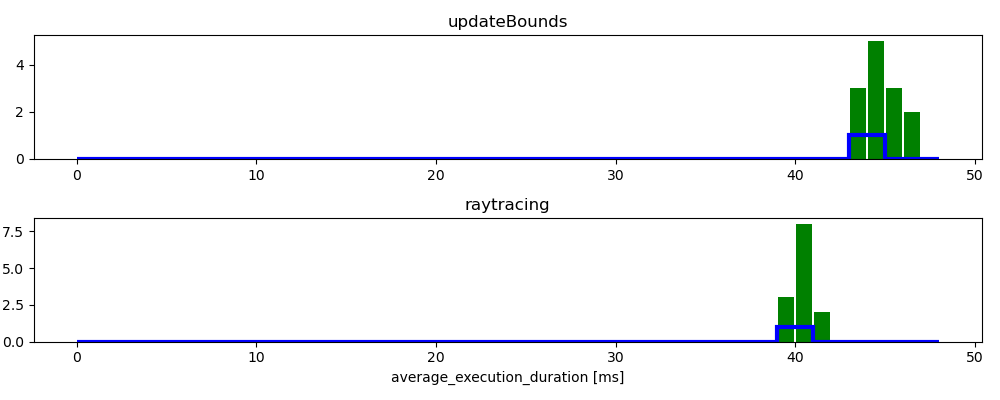

In [3]:
df_updateBounds = df[('execution_duration', 'local_costmap.updateBounds', 'average_execution_duration')] * 1000  # [ms]
df_raytracing = df[('execution_duration', 'local_costmap.raytracing', 'average_execution_duration')] * 1000  # [ms]

min_h = min(df_updateBounds.min().min(), df_raytracing.min().min())
max_h = max(df_updateBounds.max().max(), df_raytracing.max().max())
bins = np.arange(0, max_h+2, 1.0)  # 1 ms bin width
# bins = np.arange(min_h-2, max_h+2, 1.0)  # 1 ms bin width

fig, axs = plt.subplots(nrows=2, ncols=1)
axs[0].hist(list(df_updateBounds['original']), bins, density=False, histtype='barstacked', rwidth=0.9, facecolor='g')
axs[0].hist(df_updateBounds['current'], bins, density=False, histtype='step', color='blue', linewidth=3)
axs[0].set_title('updateBounds')
axs[1].hist(df_raytracing['original'], bins, density=False, histtype='barstacked', rwidth=0.9, facecolor='g')
axs[1].hist(df_raytracing['current'], bins, density=False, histtype='step', color='blue', linewidth=3)
axs[1].set_title('raytracing')
axs[1].set_xlabel('average_execution_duration [ms]')

fig.tight_layout()
plt.show()